In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# Adjust default font size so that labels are readable in plots
font = {'size': 18}
matplotlib.rc('font', **font)
matplotlib.rcParams['savefig.dpi'] = 200
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = [7, 3.5]

# Model Fitting Part I: Linear Models and Maximum Likelihood

Frequently in science, we want not just to check a hypothesis, but rather to _model_ the data. This usually involves fitting some unknown parameters to  specific functional form that we expect the data to follow. 

The simplest models are _linear_ models. 

## Fitting a Straight Line

A straight line is an example of a linear model.

We fit $y = m x + b$ with two parameters, and the model is linear in those parameters.
<b>-> x is given, y is observed and fixed once you've taken your data. The model is linear in the m and b parameters. </b>


Suppose that each observed $y_i$ have Gaussian uncertainties, with mean $mx_i+b$ and uncertainty $\sigma$ <b>-> Motivated by CLT</b>

The probability of observing $y_i$ _given_ $x_i$ and the parameters $m$ and $b$ is then 
$$
p(y_i|x_i,m, b) = \frac{1}{\sqrt{2\pi}\sigma}\exp\left(-\frac{\left[y_i-(m x_i + b)\right]^2}{2\sigma^2}\right)
$$

If I have several values measurements of (x,y) pairs and they are _independent_, then to get the total probability, I can multiply the individual probabilities. This is called a likelihood

$$
{\cal L}(y_1, \ldots y_n|x_i, \ldots x_n, m, b) = \prod_i^N p(y_i|x_i, m, b) $$

To get the maximum-likelihood solution, we maximise the likelihood as function of $m$ and $b$. <b>-> also when you take the log all the exponentials are gonna go away</b>

Maximising the likelihood is equivalent to maximising the **log** likelihood:

$$
\ln {\cal L}({y_1, \ldots y_n}|{x_i, \ldots x_n}, m, b) = \sum_i^N \ln p(y_i|x_i, m, b)$$

Since each $p_i$ is a Gaussian this becomes

\begin{align*}
\ln {\cal L}({y_1, \ldots y_n}|{x_i, \ldots x_n}, m, b) =& -N/2 \ln(2\pi) - N\ln\sigma \\
& - \sum_i^N \left(\frac{\left[y_i-(m x_i + b)\right]^2}{2\sigma^2}\right)
\end{align*}


<b>Maximizing the LHS is the same as minimizing the last term on the RHS becasue of the negative sign in  front of it. The first two terms are independent and actually don't affect the optimal m and b parameters</b>

If the $\sigma$ is known then only the second term depends on the unknowns $m$ and $b$. Maximising ${\cal L}$ reduces to _minimizing_ the sum of squares
$$
\sum_i^N \left[y_i-(m x_i + b)\right]^2
$$

Now suppose the $\sigma$ are _different_ for each measurement ($\sigma_i$), but _known_. (These are called heteroskedastic data). Then again this reduces to minimising $\chi^2$ where

$$
\chi^2 = \sum_i^N \left(\frac{\left[y_i-(m x_i + b)\right]^2}{\sigma_i^2}\right)
$$



Both of the above problems can be solved by taking derivatives w.r.t. to $m$ and $b$ and setting equal to zero (2 equations, 2 unknowns).

## Linear models

All linear models are just generalizations of the straight line fit.

For example, consider $y = a \sin x + b$. 

It's OK for the model to be non-linear wrt $x$. For example we could define $z = \sin x$. The individual $z_i$ depend only on the other data $x_i$ and not on the unknown parameters, so we can now write $y = a z + b$. 

(This would not be true if we wanted to perform the non-linear fit $y = \sin(ax) + b$. Then $z = \sin(ax)$ _does_ depend on the parameter $a$.)

Of course, in general, $y$ might be a function of more than one independent variable. For example:

$$
y = a\sin(x) + f\cos(z) + g \cos(x)\sin (z)+ c
$$

If the $x$ and $z$ are measured values with no uncertainty then it is still a linear model.
<b> Replace the sinx, cosz, cosx*sinz with A B C variables</b>

Linear models can be written
$y_i = \sum_{j=1}^{m} X_{ij}\theta_j$,
where $y_i$ is the dependent variable and the $X_{ij}$ is a row vector of _independent data_ and $\theta_1, \theta_2, \ldots \theta_m$ is a column vector of unknown _parameters_.

Now suppose there are $n$ measurements $y_i \ (i=1, 2, \dots, n)$ with the same uncertainty. 

This can be written in matrix form
$\mathbf {y} = \mathbf{X} \boldsymbol {\theta},$ where

$$
\mathbf y = \begin{bmatrix}
y_1 \\ y_2 \\ \vdots \\ y_n
\end{bmatrix}
\qquad
\mathbf {X}=\begin{bmatrix}
X_{11} & X_{12} & \cdots & X_{1m} \\
X_{21} & X_{22} & \cdots & X_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
X_{n1} & X_{n2} & \cdots & X_{nm}
\end{bmatrix} ,
\qquad 
\boldsymbol \theta = \begin{bmatrix}
\theta_1 \\ \theta_2 \\ \vdots \\ \theta_m \end{bmatrix} ,
$$

<b>Gives you a predicted y which you're gonna compare to your observed y</b>

Then this gives a system of $n$ linear equations in $m$ unknown coefficients, $\theta_1, \theta_2, \ldots \theta_m$, with $n$ > $m$.

<mark>But our goal is not to fit it (impossible), but rather to find the fit that minimises the squares of the residuals (ordinary least squares).</mark> 

There are $m$ unknown parameters, but taking the deribative of $\chi^2$ w.r.t. each of these parameters, and equating this with zero, gives $m$ equations. 

_... skipping derivation ..._

The parameter vector $\hat{\boldsymbol{\theta}}$ that minimizes the sum of squares is 
$$\hat{\boldsymbol{\theta}}= (\mathbf X^{\rm T} \mathbf X )^{-1} \mathbf X^{\rm T} \mathbf y \;.$$

<mark>So all linear models can be solved by matrix methods. This makes them fast.</mark>

The parameter vector $\hat{\boldsymbol{\theta}}$ has its own covariance matrix: <b>-> uncertainties of the parameters are related to one another (coupled) so they have cov</b>

$$\textrm{Var}[\hat{\boldsymbol{\theta}}]= \sigma^2 (\mathbf X^{\rm T} \mathbf X )^{-1}\;.$$

<mark>If we do not know $\sigma^2$ we can estimate it from the sum of the squares of the residuals divided by the number of data - number of degrees of freedom ($n-m$).</mark>
<b>-> This is if you don't know the error of the data points, it doesnt affect the fit (assuming they are all equal), this then makes the assumption that this is a good model s.t. the chi2 is equal to the number of dof. (Circular assumption so say it if you're doing it)</b>

For the case where there are weights, the answer is a bit more complicated, but it's still just linear algebra (just need to include in a few more matrices). The solution is:

$$\hat{\boldsymbol{\theta}}= (\mathbf X^{\rm T} \mathbf{W} \mathbf X )^{-1} \; \mathbf X^{\rm T} \mathbf{W} \mathbf y \;,$$

and

$$\textrm{Var}[\hat{\boldsymbol{\theta}}]= (\mathbf X^{\rm T} \mathbf{W} \mathbf X )^{-1}\;.$$


<mark>For the minimum variance estimate,  the weights are just the inverse of the covariance matrix of the data, $\mathbf{W} = \mathbf{C}^{-1}$.</mark>

##### Aside: 
Note that the linear model can include a constant. In that case we write one column of $\boldsymbol{X}$ as  populated with ones, for example $X_{i1} = 1$, with the other columns containing actual data.

For the case of estimating a mean this just corresponds to a model $y = b$, so $\mathbf{X}$ is a column of ones, and  $\mathbf{W}$ is a diagonal matrix  with $1/\sigma_i^2$ along the diagonal. 

Let's generate some mock data and then fit it. 

In [32]:
# make fake data
N = 10
m = 1.5     # true slope
b = 3.      # true intercept
sigma = 1.5 # scatter

x = 2.*np.random.randn(N) + 20         # randn is normal distr
y = m*x + b + sigma*np.random.randn(N) # add some random Gaussian noise to y

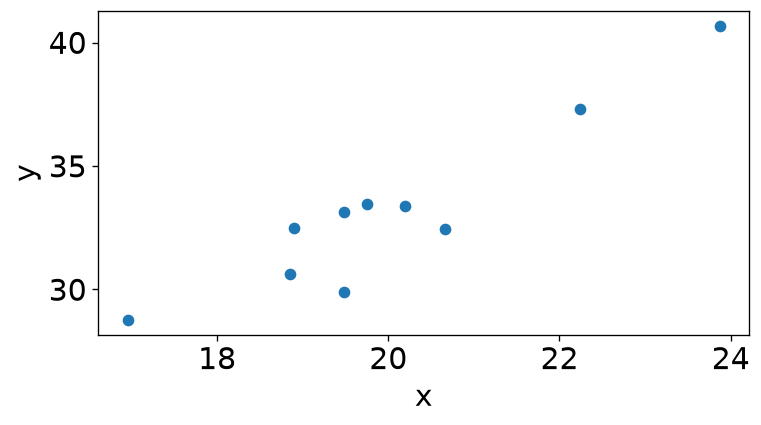

In [33]:
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y');

## Aside: Linear Algebra in Python

In [5]:
# print an numpy ndarray with extra info
def show_array(arr, name="array"):
    print(f"{name} has shape {arr.shape} with contents:")
    print(arr)

In [34]:
a = np.array([[1, 0],                   #I_2
              [0, 1]])
show_array(a,"a")
b = np.array([3, 4])
show_array(b,"b")
ans = np.matmul(a, b)
show_array(ans, "ans")

a has shape (2, 2) with contents:
[[1 0]
 [0 1]]
b has shape (2,) with contents:
[3 4]
ans has shape (2,) with contents:
[3 4]


if you just did a * b it just multiples element wise

In [7]:
ans = a @ b # prettier way of doing matrix multiplaction 
show_array(ans)

array has shape (2,) with contents:
[3 4]


[np.matmul docs](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html):

> If the second argument <b>b</b> is 1-D, it is promoted to a matrix by appending a 1 to its dimensions. After matrix multiplication the appended 1 is removed.

numpy is trying to be nice but I find it confusing

In [35]:
# convert x and y into (2D) Nx1 column vectors
N = len(x)
print("Before reshape, ", end='')
show_array(x,"x")
x = x.reshape(N, 1)
print("\nAfter reshape, ", end ='')
show_array(x,"x")

Before reshape, x has shape (10,) with contents:
[19.75109635 20.20097384 19.48530639 18.84676101 22.23514854 23.87197498
 16.95855268 20.65862061 18.89928989 19.47747752]

After reshape, x has shape (10, 1) with contents:
[[19.75109635]
 [20.20097384]
 [19.48530639]
 [18.84676101]
 [22.23514854]
 [23.87197498]
 [16.95855268]
 [20.65862061]
 [18.89928989]
 [19.47747752]]


In [36]:
# A better trick: use -1 instead of len(y) = N 
y = y.reshape(-1, 1)
show_array(y,"y")
# Note the double brackets [[ ]]

y has shape (10, 1) with contents:
[[33.45311719]
 [33.39063543]
 [29.90998752]
 [30.62271038]
 [37.29982728]
 [40.6700138 ]
 [28.76249158]
 [32.43342356]
 [32.4841427 ]
 [33.15302362]]


In [10]:
# Now make the Nx2 x array by stacking a column of ones
# (representing the constant) with the data x
X = np.hstack((np.ones_like(x), x))
print(X)

[[ 1.         18.13140618]
 [ 1.         21.32992438]
 [ 1.         17.76203331]
 [ 1.         22.69275055]
 [ 1.         18.2063067 ]
 [ 1.         20.01671381]
 [ 1.         19.99444698]
 [ 1.         21.38811845]
 [ 1.         22.9493031 ]
 [ 1.         17.75757917]]


In [11]:
# Do the matrix multiplacations using @ symbol 
theta_est = np.linalg.inv(X.T @ X)@ X.T @ y
print(theta_est) 

[[-5.34776047]
 [ 1.94937065]]


In [12]:
# change theta_est back to a simple array
theta_est = theta_est.reshape(2)
covar = sigma**2 * np.linalg.inv(X.T @ X)
print("intercept: {:.2f} +/- {:.2f}".format(theta_est[0], np.sqrt(covar[0, 0])))
print("slope    : {:.2f} +/- {:.2f}".format(theta_est[1], np.sqrt(covar[1, 1])))

intercept: -5.35 +/- 5.00
slope    : 1.95 +/- 0.25


In [13]:
print("Full covar matrix:\n", covar)

Full covar matrix:
 [[25.0164445  -1.23815712]
 [-1.23815712  0.06183718]]


But the covariance matrix can be hard to interpret, so let's calculate the correlation matrix

To do so, we need to divide each elemnt of the covariance matrix by

$$
\sqrt{C_{ii}} \sqrt{C_{jj}}
$$

In [14]:
inv_sigs  = 1./np.sqrt(np.diag(covar)) # inv of sqrt of diagonal elements
inv_sigs = inv_sigs.reshape(1,-1)      # 2D 1xN row vector
print(" The array (not matrix) which we are going to multiply element wise is:\n",inv_sigs.T @ inv_sigs)

 The array (not matrix) which we are going to multiply element wise is:
 [[ 0.03997371  0.80401169]
 [ 0.80401169 16.17150034]]


In [15]:
cor_mat = covar*(inv_sigs.T @ inv_sigs)
cor_mat

array([[ 1.       , -0.9954928],
       [-0.9954928,  1.       ]])

Slope and intercept are very strongly _anti_-correlated

In [16]:
import uncertainties
intercept, slope = uncertainties.correlated_values(theta_est, covar)
print("slope    :", slope)
print("intercept:", intercept)

slope    : 1.95+/-0.25
intercept: -5+/-5


In [17]:
xbar = np.mean(x)
yatxbar = slope*xbar+intercept
print(yatxbar)

cov2 = np.array(uncertainties.covariance_matrix([yatxbar, slope]))
print(cov2)

33.7+/-0.5
[[ 2.25000000e-01 -6.86950496e-16]
 [-6.86950496e-16  6.18371814e-02]]


## Goodness of fit: $\chi^2$

Having fitted a model, we can test whether or not it is a good fit to the data. (It might be the best fit possible, but still not an _acceptable_ fit.)

This test only makes sense if the scatter, $\sigma$ (homoskedastic) or $\sigma_i$ (heteroskedastic), is known in advance.

For a model with Gaussian residuals, the squares of these residuals should obey a $\chi^2$ distribution with $N - m$ degrees of freedom.

For the straight line fit, as above we calculate

$$
\chi^2 = \sum_i^N \left(\frac{\left[y_i-(m x_i + b)\right]^2}{\sigma_i^2}\right)
$$

and compare this with the $\chi^2$ distribution with $N-2$ d.o.f.

For the general linear fit, we replace $(m x_i + b)$ with the predicted $\hat{y_i} = \sum_{j=1}^{m} x_{ij}\hat{\theta_j}$, and calculate $\chi^2$, compare with $N-m$ d.o.f.

![image](http://www.astroml.org/_images/fig_chi2_eval_1.png)The use of the $\chi^2$ statistic for evaluating the goodness of fit. The data here are a series of observations of the luminosity of a star, with known error bars. Our model assumes that the brightness of the star does not vary; that is, all the scatter in the data is due to measurement error. $\chi^2_{\rm dof} \approx 1$ indicates that the model fits the data well (upper-left panel). $\chi^2_{\rm dof}$ much smaller than 1 (upper-right panel) is an indication that the errors are overestimated. $\chi^2_{\rm dof}$ much larger than 1 is an indication either that the errors are underestimated (lower-left panel) or that the model is not a good description of the data (lower-right panel). In this last case, it is clear from the data that the star’s luminosity is varying with time: this situation is be treated more fully in chapter 10.

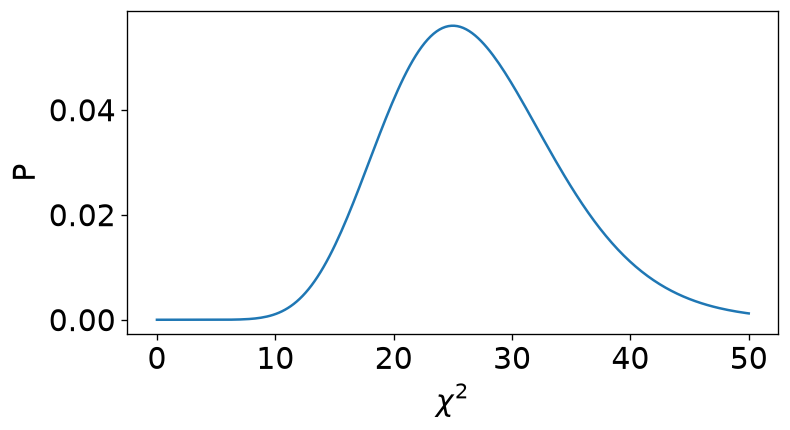

In [18]:
from scipy.stats import chi2

c = np.linspace(0,50,200)
plt.plot(c, chi2.pdf(c, df=27))
plt.xlabel(r"$\chi^2$")
plt.ylabel("P");